# Coding Exercise 2.2: Reverse OU with an estimated score

In Lecture 4 we studied the forward Ornstein–Uhlenbeck (OU) process
$$
dX_t = -X_t\,dt + \sqrt{2}\,dB_t
$$
and its time-reversal on a finite horizon $[0, T]$,
$$
dX_t^{\leftarrow}
  = \Big(X_t^{\leftarrow} + 2\,\nabla \log \rho_{T-t}(X_t^{\leftarrow})\Big)\,dt
  + \sqrt{2}\,d\widetilde B_t,
$$
where $\rho_t$ is the density of the forward process at time $t$.

In this notebook you will

1. reuse the SDE simulator from Exercise 1,
2. implement the forward OU marginal and its exact sampling formula,
3. train a **time-dependent** score model for $\rho_t$,
4. simulate the reverse OU process to generate samples.

We again use a two-mode Gaussian mixture so that the code stays close to Exercise 1 and the transition to reverse OU is as transparent as possible.


In [1]:

import numpy as np
from matplotlib import pyplot as plt

import torch
from torch import nn
from abc import ABC, abstractmethod
from tqdm.auto import tqdm
from util import Density, Sampleable, Gaussian, MixtureOfGaussians, SDE, Simulator, EulerMaruyama, OrnsteinUhlenbeck


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

np.random.seed(12345)
torch.manual_seed(12345)


Using device: cpu


## Section 1: Target distribution and plotting helpers


In [2]:

target_density = MixtureOfGaussians.two_modes_2D(distance=12.0, cov_scale=1.0).to(device)

num_train_samples = 10_000
train_x0 = target_density.sample(num_train_samples).to(device)

print("Training sample shape:", tuple(train_x0.shape))


Training sample shape: (10000, 2)


In [3]:

def make_grid(scale: float = 10.0, bins: int = 81):
    x = torch.linspace(-scale, scale, bins)
    y = torch.linspace(-scale, scale, bins)
    X, Y = torch.meshgrid(x, y, indexing="ij")
    grid = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
    return X, Y, grid


def plot_samples_on_density(ax, density: Density, samples: torch.Tensor, title: str, scale: float = 10.0):
    X, Y, grid = make_grid(scale=scale, bins=121)
    with torch.no_grad():
        log_probs = density.log_prob(grid).cpu().numpy().reshape(X.shape)

    samples_p = samples.detach().cpu().numpy()

    ax.contourf(X.cpu().numpy(), Y.cpu().numpy(), log_probs, levels=50, cmap="viridis")
    ax.scatter(samples_p[:, 0], samples_p[:, 1], s=8, alpha=0.25, color="red", edgecolors="none")
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_xlim(-scale, scale)
    ax.set_ylim(-scale, scale)
    ax.grid(alpha=0.2)


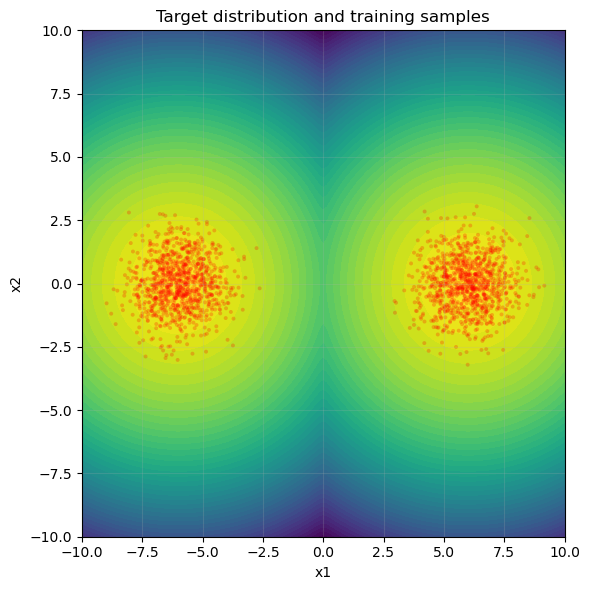

In [4]:

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plot_samples_on_density(
    ax,
    target_density,
    train_x0[:2_000],
    title="Target distribution and training samples",
    scale=10.0,
)
plt.tight_layout()
plt.show()


## Section 2: Forward OU marginals

Lecture 4 shows that for the forward OU process
$$
dX_t = -X_t\,dt + \sqrt{2}\,dB_t,
$$
the conditional law is
$$
X_t \mid X_0 = x_0 \sim \mathcal N\big(e^{-t}x_0,\ (1-e^{-2t})I\big).
$$

### 🧩 Question 2.2.1 — Implement the forward OU formula

1. Implement `sample_forward_ou(x0, t)`.
2. Implement `ou_marginal(density, t)` for `Gaussian` and `MixtureOfGaussians`.

The second function is especially useful here because our toy target is itself a mixture of Gaussians, so the noised density is still explicit.


In [5]:

def expand_time_like(t: torch.Tensor | float, x: torch.Tensor) -> torch.Tensor:
    """
    Turn a scalar or 1D tensor of times into shape (batch_size, 1) on the same device as x.
    """
    if not torch.is_tensor(t):
        t = torch.tensor(t, device=x.device, dtype=x.dtype)
    else:
        t = t.to(device=x.device, dtype=x.dtype)

    if t.ndim == 0:
        t = t.expand(x.shape[0], 1)
    elif t.ndim == 1:
        t = t.unsqueeze(1)
    return t


In [6]:
def sample_forward_ou(x0: torch.Tensor, t: torch.Tensor | float) -> torch.Tensor:
    """
    Sample X_t given X_0 = x0 from the exact OU formula
        X_t = exp(-t) X_0 + sqrt(1 - exp(-2t)) eps,
    where eps ~ N(0, I).
    """
    t = expand_time_like(t, x0)
    alpha_t = torch.exp(-t)
    sigma_t = torch.sqrt(torch.clamp(1.0 - torch.exp(-2.0 * t), min=0.0))
    eps = torch.randn_like(x0)
    return alpha_t * x0 + sigma_t * eps


def ou_marginal(density: Density, t: torch.Tensor | float) -> Density:
    """
    Return the exact forward marginal rho_t when X_0 ~ density.

    For a Gaussian component N(m, Sigma), rho_t should be
        N(exp(-t) m, exp(-2t) Sigma + (1 - exp(-2t)) I).
    """
    t_tensor = torch.as_tensor(t)
    if t_tensor.numel() > 1:
        t_flat = t_tensor.reshape(-1)
        if not torch.allclose(t_flat, t_flat[0].expand_as(t_flat), atol=1e-6):
            raise ValueError("ou_marginal expects a single time value.")
        t_scalar = t_flat[0].to(dtype=torch.float32)
    else:
        t_scalar = t_tensor.reshape(()).to(dtype=torch.float32)

    if isinstance(density, Gaussian):
        device = density.mean.device
        dtype = density.mean.dtype
        t_scalar = t_scalar.to(device=device, dtype=dtype)
        alpha_t = torch.exp(-t_scalar)
        sigma2_t = 1.0 - torch.exp(-2.0 * t_scalar)
        mean_t = alpha_t * density.mean
        cov_t = torch.exp(-2.0 * t_scalar) * density.cov + sigma2_t * torch.eye(
            density.dim, device=device, dtype=dtype
        )
        return Gaussian(mean_t, cov_t)

    if isinstance(density, MixtureOfGaussians):
        device = density.means.device
        dtype = density.means.dtype
        t_scalar = t_scalar.to(device=device, dtype=dtype)
        alpha_t = torch.exp(-t_scalar)
        sigma2_t = 1.0 - torch.exp(-2.0 * t_scalar)
        means_t = alpha_t * density.means
        covs_t = torch.exp(-2.0 * t_scalar) * density.covs + sigma2_t * torch.eye(
            density.dim, device=device, dtype=dtype
        ).unsqueeze(0)
        return MixtureOfGaussians(means_t, covs_t, density.weights)

    raise TypeError(f"Unsupported density type: {type(density).__name__}")


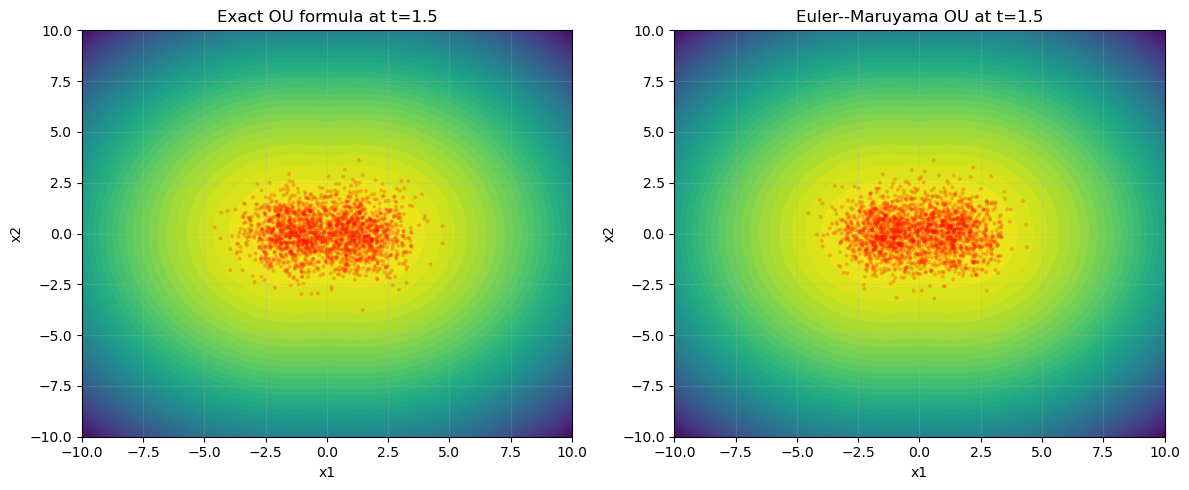

In [7]:

# Sanity check: compare exact forward sampling to Euler--Maruyama simulation.
t_vis = 1.5
num_vis = 2_000

x0_vis = target_density.sample(num_vis).to(device)
xt_exact = sample_forward_ou(x0_vis, t_vis)

ou = OrnsteinUhlenbeck(theta=1.0, sigma=np.sqrt(2.0))
ou_simulator = EulerMaruyama(ou)

ts_forward = torch.linspace(0.0, t_vis, 300, device=device)
xt_em = ou_simulator.simulate(x0_vis, ts_forward)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_samples_on_density(axes[0], ou_marginal(target_density, t_vis), xt_exact, title=f"Exact OU formula at t={t_vis}")
plot_samples_on_density(axes[1], ou_marginal(target_density, t_vis), xt_em, title=f"Euler--Maruyama OU at t={t_vis}")
plt.tight_layout()
plt.show()


## Section 3: Time-dependent score estimation

In Exercise 2.1 you implemented denoising score matching for a **fixed** Gaussian perturbation.
Here the perturbation level depends on time:
$$
X_t = \alpha_t X_0 + \sigma_t \varepsilon,
\qquad
\alpha_t = e^{-t},
\qquad
\sigma_t = \sqrt{1-e^{-2t}}.
$$

The corresponding DSM target is
$$
\nabla \log \rho_t(X_t)
\approx
-\frac{\varepsilon}{\sigma_t}
=
-\frac{X_t - \alpha_t X_0}{\sigma_t^2}.
$$


In [8]:

class TimeScoreNet(nn.Module):
    def __init__(self, dim: int = 2, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim + 1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, dim),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor | float) -> torch.Tensor:
        t = expand_time_like(t, x)
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)


### 🧩 Question 2.2.2 — Implement the OU denoising score matching loss

Complete the loss below:
$$
\mathbb E\left[\left\|s_\theta(X_t, t) + \frac{\varepsilon}{\sigma_t}\right\|_2^2\right].
$$

This is the exact analogue of Exercise 2.1, except that both the mean and the noise level now depend on time.


In [9]:
def ou_denoising_score_matching_loss(
    score_model: nn.Module,
    x0: torch.Tensor,
    t: torch.Tensor,
) -> torch.Tensor:
    """
    Implements the OU denoising score matching objective.

    Inputs
    ------
    score_model : nn.Module
        Time-dependent score network.
    x0 : torch.Tensor
        Clean samples from the data distribution, shape (batch_size, dim).
    t : torch.Tensor
        Time tensor of shape (batch_size, 1).

    Returns
    -------
    torch.Tensor
        Scalar loss.
    """
    t = expand_time_like(t, x0)
    alpha_t = torch.exp(-t)
    sigma_t = torch.sqrt(torch.clamp(1.0 - torch.exp(-2.0 * t), min=1e-12))

    eps = torch.randn_like(x0)
    xt = alpha_t * x0 + sigma_t * eps

    predicted_score = score_model(xt, t)
    residual = predicted_score + eps / sigma_t
    return (residual ** 2).sum(dim=1).mean()


### 🧩 Question 2.2.3 — Train the time-dependent score model

Suggested hyper-parameters are provided below.  Increase `num_steps` if you want sharper results.


In [10]:

T = 4.0
t_min = 0.05

time_score_model = TimeScoreNet(dim=2, hidden_dim=64).to(device)
optimizer = torch.optim.Adam(time_score_model.parameters(), lr=1e-3)

batch_size = 256
num_steps = 1_200
train_loss_history = []

for step in tqdm(range(num_steps)):
    idx = torch.randint(0, train_x0.shape[0], (batch_size,), device=device)
    x0_batch = train_x0[idx]
    t_batch = t_min + (T - t_min) * torch.rand(batch_size, 1, device=device)

    loss = ou_denoising_score_matching_loss(time_score_model, x0_batch, t_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss_history.append(loss.item())


  0%|          | 0/1200 [00:00<?, ?it/s]

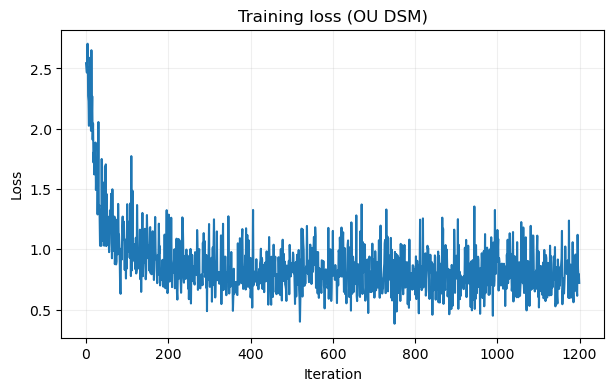

In [11]:

plt.figure(figsize=(7, 4))
plt.plot(train_loss_history)
plt.title("Training loss (OU DSM)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(alpha=0.2)
plt.show()


### 🧩 Question 2.2.4 — Compare learned and exact scores at fixed times

Use the explicit `ou_marginal` function to compare your network with the true score of $\rho_t$ at a few time points.


In [12]:

def plot_time_score_comparison(
    base_density: Density,
    score_model: nn.Module,
    t: float,
    scale: float = 10.0,
    bins: int = 31,
    stride: int = 2,
):
    X, Y, grid = make_grid(scale=scale, bins=bins)
    exact_density = ou_marginal(base_density, t)

    with torch.no_grad():
        log_probs = exact_density.log_prob(grid).cpu().numpy().reshape(X.shape)
        predicted_score = score_model(grid, torch.full((grid.shape[0], 1), t, device=device)).cpu().numpy().reshape(bins, bins, 2)

    exact_score = exact_density.score(grid).detach().cpu().numpy().reshape(bins, bins, 2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, score, title in zip(
        axes,
        [exact_score, predicted_score],
        [f"Exact score at t={t}", f"Learned score at t={t}"],
    ):
        ax.contourf(X.cpu().numpy(), Y.cpu().numpy(), log_probs, levels=40, cmap="viridis")
        ax.quiver(
            X.cpu().numpy()[::stride, ::stride],
            Y.cpu().numpy()[::stride, ::stride],
            score[::stride, ::stride, 0],
            score[::stride, ::stride, 1],
            color="white",
            alpha=0.9,
        )
        ax.set_title(title)
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")
        ax.set_xlim(-scale, scale)
        ax.set_ylim(-scale, scale)
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()


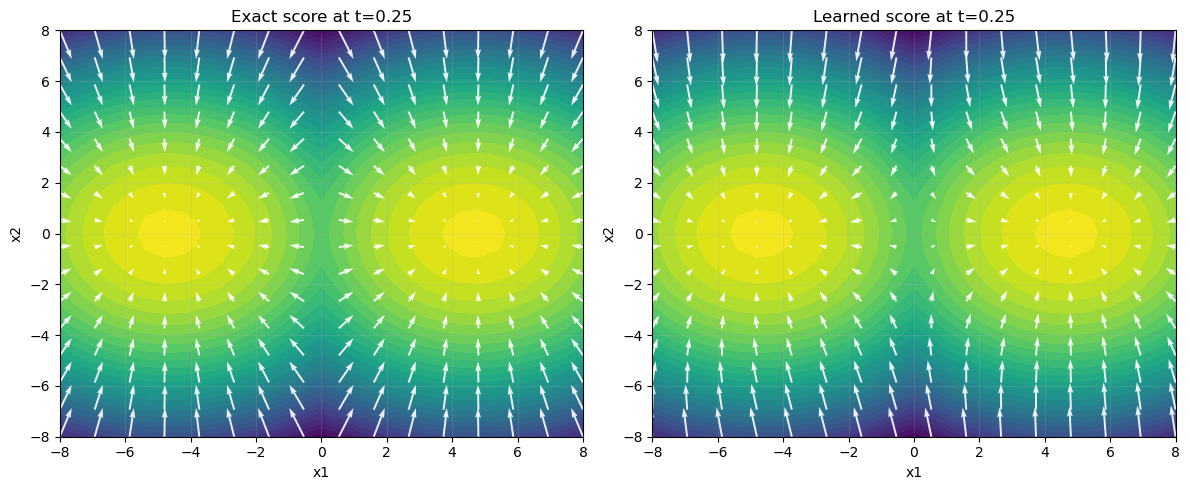

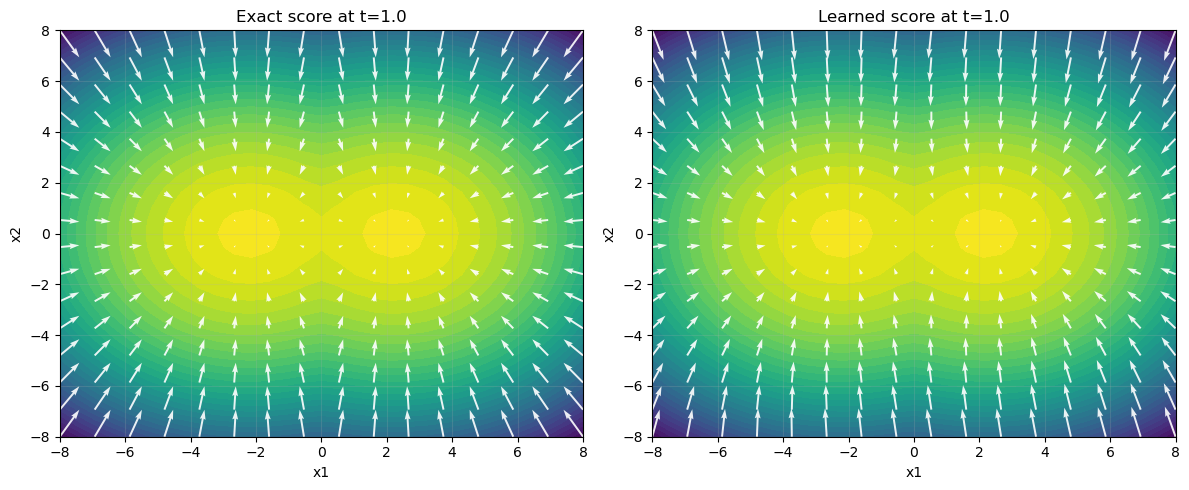

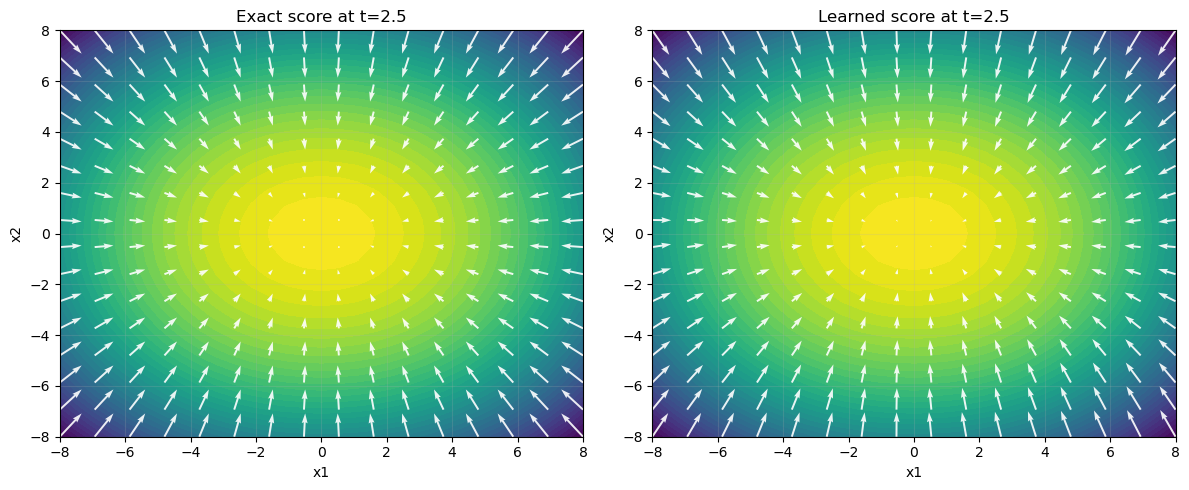

In [13]:

for t_eval in [0.25, 1.0, 2.5]:
    plot_time_score_comparison(target_density, time_score_model, t=t_eval, scale=8.0)


## Section 4: Reverse OU

The reverse-time SDE from Lecture 4 is
$$
dX_t^{\leftarrow}
  = \Big(X_t^{\leftarrow} + 2\,\nabla \log \rho_{T-t}(X_t^{\leftarrow})\Big)\,dt
  + \sqrt{2}\,d\widetilde B_t.
$$

### 🧩 Question 2.2.5 — Implement the reverse OU SDE

Complete the class below.  The argument `score_fn(x, t)` should return an estimate of the score at **forward time** `t`.


In [14]:
class ReverseOU(SDE):
    def __init__(self, score_fn, T: float):
        self.score_fn = score_fn
        self.T = T

    def drift(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        t_forward = self.T - t
        return x + 2.0 * self.score_fn(x, t_forward)

    def diffusion(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        return np.sqrt(2.0) * torch.ones_like(x)


### 🧩 Question 2.2.6 — Sanity check with the exact score

Before using the learned score, it is a good idea to test your reverse OU implementation with the **exact** score.
Start from the exact forward marginal $\rho_T$ and check whether the reverse process recovers samples that look like the original target distribution.


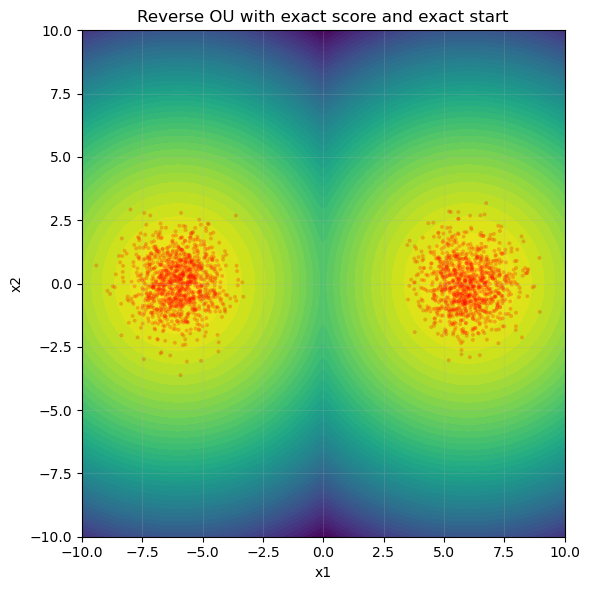

In [15]:

def exact_ou_score(x: torch.Tensor, t: torch.Tensor | float) -> torch.Tensor:
    t_tensor = expand_time_like(t, x)
    if not torch.allclose(t_tensor, t_tensor[:1].expand_as(t_tensor), atol=1e-6):
        raise ValueError("This helper expects the same time for the whole batch.")
    t_scalar = float(t_tensor[0, 0].detach().cpu().item())
    return ou_marginal(target_density, t_scalar).score(x)


num_reverse_samples = 2_000
ts_reverse = torch.linspace(0.0, T, 300, device=device)

reverse_exact = ReverseOU(score_fn=exact_ou_score, T=T)
reverse_exact_simulator = EulerMaruyama(reverse_exact)

xT_exact = ou_marginal(target_density, T).sample(num_reverse_samples).to(device)
x0_recovered = reverse_exact_simulator.simulate(xT_exact, ts_reverse)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plot_samples_on_density(
    ax,
    target_density,
    x0_recovered,
    title="Reverse OU with exact score and exact start",
    scale=10.0,
)
plt.tight_layout()
plt.show()


### 🧩 Question 2.2.7 — Generate from Gaussian noise with the learned score

In practice we do not know the exact $\rho_T$, but for large $T$ the OU process is close to its invariant Gaussian distribution.
Therefore we start from
$$
X_T \approx \mathcal N(0, I)
$$
and run the reverse OU dynamics with the learned score.


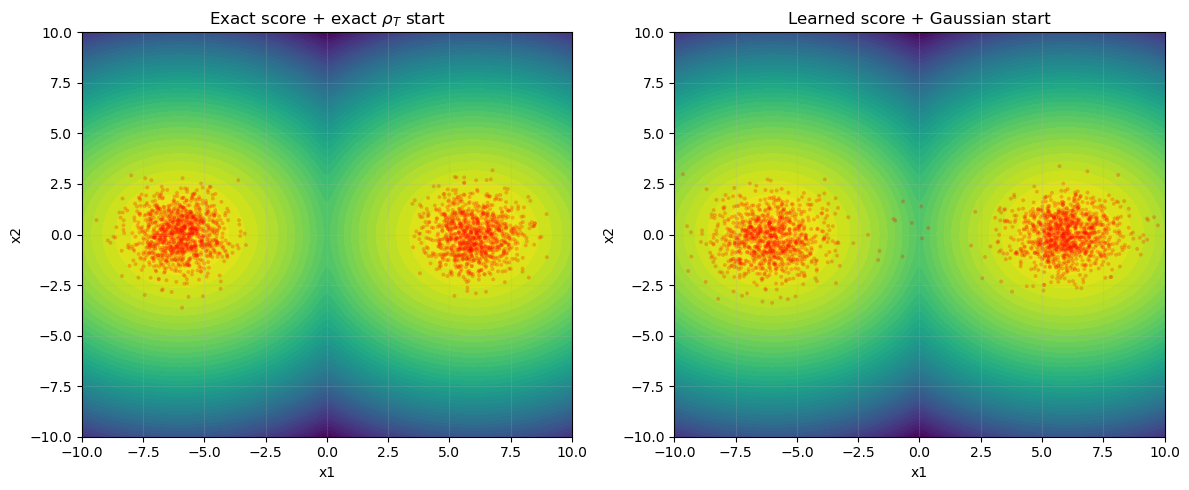

In [16]:
time_score_model.eval()

reverse_learned = ReverseOU(score_fn=lambda x, t: time_score_model(x, t), T=T)
reverse_learned_simulator = EulerMaruyama(reverse_learned)

xT_gaussian = torch.randn(num_reverse_samples, 2, device=device)
x0_generated = reverse_learned_simulator.simulate(xT_gaussian, ts_reverse)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_samples_on_density(
    axes[0],
    target_density,
    x0_recovered,
    title=r"Exact score + exact $\rho_T$ start",
    scale=10.0,
)
plot_samples_on_density(
    axes[1],
    target_density,
    x0_generated,
    title="Learned score + Gaussian start",
    scale=10.0,
)
plt.tight_layout()
plt.show()


### 🧩 Question 2.2.8 — Discussion

Answer the following in a markdown cell below.

1. What are the two main approximation errors in the practical sampler above?
   - finite time horizon `T`,
   - score estimation error.
2. What changes if `T` is too small?
3. What changes if the modes are moved farther apart?
4. Why should reverse OU move between modes more easily than plain Langevin dynamics from Exercise 1?

**Optional extension.**  
Reuse your `Langevin` class from Exercise 1 and compare the final samples side by side.


_Write your answer here._
